<a href="https://colab.research.google.com/github/kimjiwoo0603/Cart-To-Chart/blob/namjiwon/%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%8B%9C%EA%B0%81%ED%99%94_project1_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#라이브러리 불러오기
import pandas as pd
import os

In [ ]:
#CSV 파일 위치 지정
file_path = "/content/drive/MyDrive/amazon-purchases.csv"
os.path.exists(file_path)

True

In [ ]:
#1000개 sample 확인
pd.read_csv(file_path)
df_sample = pd.read_csv(file_path, nrows=1000)
df_sample.head()

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [ ]:
#sample에서의 column 확인
df_sample.columns

Index(['Order Date', 'Purchase Price Per Unit', 'Quantity',
       'Shipping Address State', 'Title', 'ASIN/ISBN (Product Code)',
       'Category', 'Survey ResponseID'],
      dtype='object')

In [ ]:
#자료형 확인
#Order Date 날짜형으로 변환 필요
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order Date                1000 non-null   object 
 1   Purchase Price Per Unit   1000 non-null   float64
 2   Quantity                  1000 non-null   float64
 3   Shipping Address State    982 non-null    object 
 4   Title                     952 non-null    object 
 5   ASIN/ISBN (Product Code)  1000 non-null   object 
 6   Category                  952 non-null    object 
 7   Survey ResponseID         1000 non-null   object 
dtypes: float64(2), object(6)
memory usage: 62.6+ KB


In [ ]:
#sample 결측치 확인
df_sample.isna().sum()

,0
Order Date,0
Purchase Price Per Unit,0
Quantity,0
Shipping Address State,18
Title,48
ASIN/ISBN (Product Code),0
Category,48
Survey ResponseID,0


In [ ]:
#카테고리 수 확
df_sample["Category"].value_counts(dropna=False)
df_sample["Category"].nunique()

304

In [ ]:
#Title, Category 연결 관계 확인
df_sample[["Title", "Category"]].head(30)

,Title,Category
0,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,FLASH_MEMORY
1,Betron BS10 Earphones Wired Headphones in Ear ...,HEADPHONES
2,NaN,NaN
3,Perfecto Stainless Steel Shaving Bowl. Durable...,DISHWARE_BOWL
4,Proraso Shaving Cream for Men,SHAVING_AGENT
5,Micro USB Cable Android Charger - Syncwire [2-...,COMPUTER_PROCESSOR
6,Amazon Basics USB 2.0 Charger Cable - A-Male t...,COMPUTER_ADD_ON
7,"Fire HD 8 Tablet (8"" HD Display, 32 GB, withou...",AMAZON_TABLET
8,"Men's Leather Belt, Ratchet Dress Belt with Au...",APPAREL_BELT
9,NaN,NaN


In [ ]:
#전처리 시작
#Order Date의 Dtype 확인
df_sample["Order Date"].head(10)

,Order Date
0,2018-12-04
1,2018-12-22
2,2018-12-24
3,2018-12-25
4,2018-12-25
5,2019-02-18
6,2019-02-18
7,2019-03-15
8,2019-04-23
9,2019-04-23


In [ ]:
#Order Dtype object->날짜형으로 변환
df_sample["Order Date"] = pd.to_datetime(df_sample["Order Date"])

In [ ]:
df_sample["Order Date"].dtype

dtype('<M8[ns]')

In [ ]:
df_sample["Order Date"].head()

,Order Date
0,2018-12-04
1,2018-12-22
2,2018-12-24
3,2018-12-25
4,2018-12-25


In [ ]:
#구매 금액 계산
df_sample["Purchase Amount"] = (
    df_sample["Purchase Price Per Unit"] * df_sample["Quantity"]
)

In [ ]:
df_sample[
    ["Purchase Price Per Unit", "Quantity", "Purchase Amount"]
].head(10)

,Purchase Price Per Unit,Quantity,Purchase Amount
0,7.98,1.0,7.98
1,13.99,1.0,13.99
2,8.99,1.0,8.99
3,10.45,1.0,10.45
4,10.00,1.0,10.00
5,10.99,1.0,10.99
6,4.99,1.0,4.99
7,124.99,1.0,124.99
8,12.99,1.0,12.99
9,24.69,1.0,24.69


In [ ]:
# 평균보다 중앙값이 꽤 낮고 최대값이 $483이니까, 가격이 높은 상품이 일부 섞여 있을 가능성 있음
df_sample["Purchase Amount"].describe()

,Purchase Amount
count,1000.000000
mean,16.526040
std,28.761087
min,0.750000
25%,5.462500
50%,10.000000
75%,16.990000
max,483.000000


In [ ]:
#결측치 확인
df_sample["ASIN/ISBN (Product Code)"].isna().sum()

np.int64(0)

In [ ]:
(df_sample["ASIN/ISBN (Product Code)"] == "").sum()

np.int64(0)

In [ ]:
#Gift Card 개수 구하기
df_sample["Title"].dropna().str.upper().str.contains("GIFT CARD").sum()

np.int64(18)

In [ ]:
df_sample[
    df_sample["ASIN/ISBN (Product Code)"].str.len() != 10
]["ASIN/ISBN (Product Code)"].head(20)

,ASIN/ISBN (Product Code)


In [ ]:
(df_sample["ASIN/ISBN (Product Code)"].str.len() != 10).sum()

np.int64(0)

In [ ]:
#Gift Card 건수 파악하기
#32859건 제외해야 함(Google Trend, Review와 연결하기 모호한 카테고리)
gift_card_count = 0

for chunk in pd.read_csv(file_path, chunksize=100000):
    title = chunk["Title"].fillna("").str.upper()
    gift_card_count += title.str.contains("GIFT CARD", na=False).sum()

gift_card_count

np.int64(32859)

In [ ]:
#중복된 구매 기록 건수 확인
df_sample.duplicated().sum()

np.int64(3)

In [ ]:
#중복된 열 불러오기
#은 상품을 같은 날짜에 두 번 기록한 것이 데이터 수집 과정에서 중복된 것인지, 아니면 실제 구매기록의 중복인지 알 수 없음.판단 필요
df_sample[df_sample.duplicated(keep=False)]

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Purchase Amount
33,2019-10-06,50.0,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF,50.0
34,2019-10-06,50.0,1.0,NaN,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF,50.0
597,2021-01-04,200.0,1.0,NaN,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_037XK72IZBJyF69,200.0
598,2021-01-04,200.0,1.0,NaN,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_037XK72IZBJyF69,200.0
688,2021-03-02,5.3,1.0,PA,Korean & English - A Bilingual Adult Coloring ...,1539300927,ABIS_BOOK,R_037XK72IZBJyF69,5.3
689,2021-03-02,5.3,1.0,PA,Korean & English - A Bilingual Adult Coloring ...,1539300927,ABIS_BOOK,R_037XK72IZBJyF69,5.3


In [ ]:
#Gift Card 제외
#전체의 약 1.78%
total_rows = 0
gift_card_rows = 0
remaining_rows = 0

for chunk in pd.read_csv(file_path, chunksize=100000):
    total_rows += len(chunk)

    title = chunk["Title"].fillna("").str.upper()
    is_gift_card = title.str.contains("GIFT CARD", na=False)

    gift_card_rows += is_gift_card.sum()
    remaining_rows += (~is_gift_card).sum()

print("전체 행:", total_rows)
print("Gift Card:", gift_card_rows)
print("남은 행:", remaining_rows)

전체 행: 1850717
Gift Card: 32859
남은 행: 1817858


In [ ]:
#중복 data 확인
#주의! 실제로 같은 상품을 같은 날 두 번 구매한 정상 거래 있을 수 있음
duplicate_count = 0

for chunk in pd.read_csv(file_path, chunksize=100000):
    chunk["Order Date"] = pd.to_datetime(chunk["Order Date"])

    dup = chunk.duplicated(
        subset=[
            "Survey ResponseID",
            "Order Date",
            "ASIN/ISBN (Product Code)",
            "Quantity",
            "Purchase Price Per Unit"
        ],
        keep=False
    )

    duplicate_count += dup.sum()

print("중복 후보 행:", duplicate_count)

중복 후보 행: 19675


In [ ]:
duplicate_examples = []

for chunk in pd.read_csv(file_path, chunksize=100000):
    dup = chunk.duplicated(
        subset=[
            "Survey ResponseID",
            "Order Date",
            "ASIN/ISBN (Product Code)",
            "Quantity",
            "Purchase Price Per Unit"
        ],
        keep=False
    )

    if dup.any():
        duplicate_examples.append(
            chunk.loc[dup, [
                "Order Date",
                "Purchase Price Per Unit",
                "Quantity",
                "Title",
                "ASIN/ISBN (Product Code)",
                "Category",
                "Survey ResponseID"
            ]]
        )

duplicate_examples = pd.concat(duplicate_examples, ignore_index=True)

duplicate_examples.head(20)

,Order Date,Purchase Price Per Unit,Quantity,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2019-10-06,50.00,1.0,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
1,2019-10-06,50.00,1.0,Best Buy Gift Cards - Email Delivery,B07RTN4C77,GIFT_CARD,R_01vNIayewjIIKMF
2,2021-01-04,200.00,1.0,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_037XK72IZBJyF69
3,2021-01-04,200.00,1.0,Amazon.com Gift Card Balance Reload,B00IX1I3G6,GIFT_CARD,R_037XK72IZBJyF69
4,2021-03-02,5.30,1.0,Korean & English - A Bilingual Adult Coloring ...,1539300927,ABIS_BOOK,R_037XK72IZBJyF69
5,2021-03-02,5.30,1.0,Korean & English - A Bilingual Adult Coloring ...,1539300927,ABIS_BOOK,R_037XK72IZBJyF69
6,2022-03-20,26.99,1.0,Twinings Irish Breakfast Individually Wrapped ...,B000F4H5GI,TEA,R_037XK72IZBJyF69
7,2022-03-20,26.99,1.0,Twinings Irish Breakfast Individually Wrapped ...,B000F4H5GI,TEA,R_037XK72IZBJyF69
8,2021-11-21,65.95,1.0,Northland School-Years Picture Frame Personali...,B074G581TG,PICTURE_FRAME,R_06RZP9pS7kONINr
9,2021-11-21,65.95,1.0,Northland School-Years Picture Frame Personali...,B074G581TG,PICTURE_FRAME,R_06RZP9pS7kONINr


In [ ]:
#중복치 많은 카테고리 확인
duplicate_examples["Category"].value_counts().head(20)

,count
Category,
GIFT_CARD,6275
ABIS_GIFT_CARD,1433
ABIS_BOOK,1063
PET_FOOD,560
ELECTRONIC_GIFT_CARD,530
DOWNLOADABLE_VIDEO_GAME,332
NUTRITIONAL_SUPPLEMENT,247
SHIRT,231
SNACK_FOOD_BAR,176


In [ ]:
#Gift Card 카테고리 목록 확인
# 'GIFT_WRAP','GIFT_XXRD' 기프트카드가 아닐 수 있음. 확인 필
gift_categories = []

for chunk in pd.read_csv(file_path, chunksize=100000):
    categories = chunk["Category"].dropna().astype(str)

    for category in categories.unique():
        if "GIFT" in category.upper():
            gift_categories.append(category)

sorted(set(gift_categories))

['ABIS_GIFT_CARD',
 'CONSUMABLES_EMAIL_GIFT_CARD',
 'ELECTRONIC_GIFT_CARD',
 'ELECTRONIC_GIFT_XXRD',
 'Ecard Gift Certificate',
 'GIFTS_AND_OCCASIONS',
 'GIFT_CARD',
 'GIFT_WRAP',
 'GIFT_XXRD',
 'NONACTIVATED_GIFT_CARD',
 'PHYSICAL_GIFT_CARD']

In [ ]:
for category in sorted(set(gift_categories)):
    count = 0

    for chunk in pd.read_csv(file_path, chunksize=100000):
        count += (chunk["Category"] == category).sum()

    print(category, ":", count)

ABIS_GIFT_CARD : 5947
CONSUMABLES_EMAIL_GIFT_CARD : 18
ELECTRONIC_GIFT_CARD : 2975
ELECTRONIC_GIFT_XXRD : 2
Ecard Gift Certificate : 38
GIFTS_AND_OCCASIONS : 2
GIFT_CARD : 27734
GIFT_WRAP : 2074
GIFT_XXRD : 6
NONACTIVATED_GIFT_CARD : 1
PHYSICAL_GIFT_CARD : 78


In [ ]:
import pandas as pd

output_path = "/content/drive/MyDrive/amazon-purchases-cleaned.csv"

keep_cols = [
    "Order Date",
    "Purchase Price Per Unit",
    "Quantity",
    "Shipping Address State",
    "Title",
    "ASIN/ISBN (Product Code)",
    "Category",
    "Survey ResponseID"
]

first_chunk = True

for chunk in pd.read_csv(file_path, chunksize=100000):

    # 1. 날짜 변환
    chunk["Order Date"] = pd.to_datetime(chunk["Order Date"])

    # 2. 구매금액 계산
    chunk["Purchase Amount"] = (
        chunk["Purchase Price Per Unit"] * chunk["Quantity"]
    )

    # 3. Gift Card 제거
    title = chunk["Title"].fillna("").astype(str).str.upper()
    category = chunk["Category"].fillna("").astype(str).str.upper()

    gift_by_title = title.str.contains("GIFT CARD", na=False)

    gift_categories = [
        "ABIS_GIFT_CARD",
        "CONSUMABLES_EMAIL_GIFT_CARD",
        "ELECTRONIC_GIFT_CARD",
        "ELECTRONIC_GIFT_XXRD",
        "ECARD GIFT CERTIFICATE",
        "GIFT_CARD",
        "GIFT_XXRD",
        "NONACTIVATED_GIFT_CARD",
        "PHYSICAL_GIFT_CARD"
    ]

    gift_by_category = category.isin(gift_categories)

    chunk = chunk[~(gift_by_title | gift_by_category)]

    # 4. 필요한 컬럼만 유지
    chunk = chunk[
        keep_cols + ["Purchase Amount"]
    ]

    # 5. CSV 저장
    chunk.to_csv(
        output_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("전처리 완료!")
print(output_path)

전처리 완료!
/content/drive/MyDrive/amazon-purchases-cleaned.csv


In [ ]:
cleaned_path = "/content/drive/MyDrive/amazon-purchases-cleaned.csv"

df_clean_sample = pd.read_csv(cleaned_path, nrows=1000)

print(df_clean_sample.shape)
print(df_clean_sample.columns)

(1000, 9)
Index(['Order Date', 'Purchase Price Per Unit', 'Quantity',
       'Shipping Address State', 'Title', 'ASIN/ISBN (Product Code)',
       'Category', 'Survey ResponseID', 'Purchase Amount'],
      dtype='object')


In [ ]:
df_clean_sample.head()

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID,Purchase Amount
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF,7.98
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF,13.99
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF,8.99
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF,10.45
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF,10.00


In [ ]:
title = df_clean_sample["Title"].fillna("").astype(str).str.upper()
category = df_clean_sample["Category"].fillna("").astype(str).str.upper()

print("Title에 GIFT CARD 포함:", title.str.contains("GIFT CARD").sum())
print("Category에 GIFT CARD 포함:", category.str.contains("GIFT_CARD").sum())

Title에 GIFT CARD 포함: 0
Category에 GIFT CARD 포함: 0


In [ ]:
total_rows = 0

for chunk in pd.read_csv(cleaned_path, chunksize=100000):
    total_rows += len(chunk)

print("전처리 후 전체 행:", total_rows)

전처리 후 전체 행: 1809241


In [ ]:
missing_counts = {}

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    for col in chunk.columns:
        missing_counts[col] = (
            missing_counts.get(col, 0)
            + chunk[col].isna().sum()
        )

missing_counts = pd.Series(missing_counts).sort_values(ascending=False)

print(missing_counts)

Title                       89687
Category                    89456
Shipping Address State      50448
ASIN/ISBN (Product Code)      953
Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Survey ResponseID               0
Purchase Amount                 0
dtype: int64


In [ ]:
missing_relation = {
    "ASIN 있음 + Title 없음": 0,
    "ASIN 있음 + Category 없음": 0,
    "ASIN 없음 + Title 없음": 0,
    "ASIN 없음 + Category 없음": 0
}

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    asin_missing = chunk["ASIN/ISBN (Product Code)"].isna()
    title_missing = chunk["Title"].isna()
    category_missing = chunk["Category"].isna()

    missing_relation["ASIN 있음 + Title 없음"] += (
        (~asin_missing) & title_missing
    ).sum()

    missing_relation["ASIN 있음 + Category 없음"] += (
        (~asin_missing) & category_missing
    ).sum()

    missing_relation["ASIN 없음 + Title 없음"] += (
        asin_missing & title_missing
    ).sum()

    missing_relation["ASIN 없음 + Category 없음"] += (
        asin_missing & category_missing
    ).sum()

print(pd.Series(missing_relation))

ASIN 있음 + Title 없음       89362
ASIN 있음 + Category 없음    89058
ASIN 없음 + Title 없음         325
ASIN 없음 + Category 없음      398
dtype: int64


In [ ]:
#ASIN으로 결측치를 복구할 수 있는지 확인
asin_info = {}

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    temp = chunk[
        ["ASIN/ISBN (Product Code)", "Title", "Category"]
    ].dropna(subset=["ASIN/ISBN (Product Code)"])

    for asin, group in temp.groupby("ASIN/ISBN (Product Code)"):

        if asin not in asin_info:
            asin_info[asin] = {
                "title_exists": False,
                "category_exists": False
            }

        if group["Title"].notna().any():
            asin_info[asin]["title_exists"] = True

        if group["Category"].notna().any():
            asin_info[asin]["category_exists"] = True

print("ASIN 개수:", len(asin_info))

ASIN 개수: 937293


In [ ]:
# ASIN별로 알려진 Title / Category가 있는지 확인
asin_title_exists = set()
asin_category_exists = set()

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    # Title이 존재하는 ASIN
    temp = chunk.dropna(subset=["ASIN/ISBN (Product Code)", "Title"])
    asin_title_exists.update(
        temp["ASIN/ISBN (Product Code)"].unique()
    )

    # Category가 존재하는 ASIN
    temp = chunk.dropna(subset=["ASIN/ISBN (Product Code)", "Category"])
    asin_category_exists.update(
        temp["ASIN/ISBN (Product Code)"].unique()
    )

print("Title이 존재하는 ASIN:", len(asin_title_exists))
print("Category가 존재하는 ASIN:", len(asin_category_exists))

Title이 존재하는 ASIN: 874649
Category가 존재하는 ASIN: 874769


In [ ]:
#ASIN이 있다고 해서 대부분의 결측을 복구할 수 있는 건 아님
title_recoverable = 0
category_recoverable = 0

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    asin = chunk["ASIN/ISBN (Product Code)"]

    title_missing = chunk["Title"].isna()
    category_missing = chunk["Category"].isna()

    title_recoverable += (
        title_missing &
        asin.isin(asin_title_exists)
    ).sum()

    category_recoverable += (
        category_missing &
        asin.isin(asin_category_exists)
    ).sum()

print("ASIN으로 Title 복구 가능한 결측 행:", title_recoverable)
print("ASIN으로 Category 복구 가능한 결측 행:", category_recoverable)

ASIN으로 Title 복구 가능한 결측 행: 3584
ASIN으로 Category 복구 가능한 결측 행: 3188


In [ ]:
asin_title_values = {}
asin_category_values = {}

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    temp = chunk.dropna(subset=["ASIN/ISBN (Product Code)"])

    for asin, group in temp.groupby("ASIN/ISBN (Product Code)"):

        titles = group["Title"].dropna().unique()
        categories = group["Category"].dropna().unique()

        if len(titles) > 0:
            asin_title_values.setdefault(asin, set()).update(titles)

        if len(categories) > 0:
            asin_category_values.setdefault(asin, set()).update(categories)

# 서로 다른 Title이 2개 이상인 ASIN
multiple_titles = sum(
    len(values) > 1
    for values in asin_title_values.values()
)

# 서로 다른 Category가 2개 이상인 ASIN
multiple_categories = sum(
    len(values) > 1
    for values in asin_category_values.values()
)

print("서로 다른 Title이 2개 이상인 ASIN:", multiple_titles)
print("서로 다른 Category가 2개 이상인 ASIN:", multiple_categories)

서로 다른 Title이 2개 이상인 ASIN: 27516
서로 다른 Category가 2개 이상인 ASIN: 17058


In [ ]:
price_stats = []
quantity_stats = []
amount_stats = []

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    price_stats.append(chunk["Purchase Price Per Unit"])
    quantity_stats.append(chunk["Quantity"])
    amount_stats.append(chunk["Purchase Amount"])

price = pd.concat(price_stats)
quantity = pd.concat(quantity_stats)
amount = pd.concat(amount_stats)

print("=== Price ===")
print(price.describe())

print("\n=== Quantity ===")
print(quantity.describe())

print("\n=== Purchase Amount ===")
print(amount.describe())
print("가격 <= 0:", (price <= 0).sum())
print("수량 <= 0:", (quantity <= 0).sum())
print("구매금액 <= 0:", (amount <= 0).sum())

=== Price ===
count    1.809241e+06
mean     2.249931e+01
std      4.600769e+01
min      1.000000e-02
25%      8.490000e+00
50%      1.399000e+01
75%      2.299000e+01
max      6.398950e+03
Name: Purchase Price Per Unit, dtype: float64

=== Quantity ===
count    1.809241e+06
mean     1.089490e+00
std      7.815645e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.390000e+02
Name: Quantity, dtype: float64

=== Purchase Amount ===
count    1.809241e+06
mean     2.361809e+01
std      4.869092e+01
min      1.000000e-02
25%      8.970000e+00
50%      1.461000e+01
75%      2.424000e+01
max      6.398950e+03
Name: Purchase Amount, dtype: float64
가격 <= 0: 0
수량 <= 0: 0
구매금액 <= 0: 0


In [ ]:
duplicate_rows = 0
total_rows = 0

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    total_rows += len(chunk)
    duplicate_rows += chunk.duplicated().sum()

print("전체 행:", total_rows)
print("완전히 동일한 중복 행:", duplicate_rows)

전체 행: 1809241
완전히 동일한 중복 행: 5306


In [ ]:
category_counts = {}

for chunk in pd.read_csv(cleaned_path, chunksize=100000):

    counts = chunk["Category"].value_counts()

    for category, count in counts.items():
        category_counts[category] = (
            category_counts.get(category, 0) + count
        )

category_counts = pd.Series(category_counts).sort_values(
    ascending=False
)

print(category_counts.head(30))

ABIS_BOOK                 87417
PET_FOOD                  38256
SHIRT                     27267
NUTRITIONAL_SUPPLEMENT    26913
ELECTRONIC_CABLE          18268
HEALTH_PERSONAL_CARE      16624
MEDICATION                16185
PANTS                     15944
CELLULAR_PHONE_CASE       15370
SKIN_MOISTURIZER          13666
SHOES                     12758
FOOD                      12452
GROCERY                   12112
VEGETABLE                 12073
TOYS_AND_GAMES            11626
TOY_FIGURE                11538
SKIN_CLEANING_AGENT       11415
HEADPHONES                11386
VITAMIN                   10908
PET_SUPPLIES              10902
COFFEE                    10761
CLEANING_AGENT            10612
BATTERY                   10415
SOCKS                     10170
DRINK_FLAVORED             9775
SCREEN_PROTECTOR           9327
BEAUTY                     8894
HERBAL_SUPPLEMENT          8728
WRITING_INSTRUMENT         8483
FRUIT                      8323
dtype: int64


In [ ]:
print(category_counts.head(100))

In [ ]:
weekly_category = {}

for chunk in pd.read_csv(
    cleaned_path,
    chunksize=100000,
    parse_dates=["Order Date"]
):

    chunk["Week"] = chunk["Order Date"].dt.to_period("W").dt.start_time

    weekly = (
        chunk.groupby(["Category", "Week"])
        .size()
        .reset_index(name="Purchase_Count")
    )

    for _, row in weekly.iterrows():
        key = (row["Category"], row["Week"])
        weekly_category[key] = (
            weekly_category.get(key, 0) + row["Purchase_Count"]
        )

weekly_category_df = pd.DataFrame(
    [
        [category, week, count]
        for (category, week), count in weekly_category.items()
    ],
    columns=["Category", "Week", "Purchase_Count"]
)

print(weekly_category_df.head())
print("행 수:", len(weekly_category_df))


     Category       Week  Purchase_Count
0  3D_PRINTER 2020-03-09               1
1  3D_PRINTER 2020-06-01               1
2  3D_PRINTER 2020-12-14               1
3  3D_PRINTER 2021-03-15               4
4  3D_PRINTER 2021-04-05               2
행 수: 256765


In [ ]:
category_weekly_stats = (
    weekly_category_df
    .groupby("Category")["Purchase_Count"]
    .agg(
        median="median",
        mean="mean",
        max="max",
        weeks="count"
    )
    .sort_values("median", ascending=False)
)

print(category_weekly_stats.head(50))

In [ ]:
candidate_categories = category_weekly_stats[
    category_weekly_stats["median"] >= 20
]

print(candidate_categories)
print("후보 Category 수:", len(candidate_categories))

In [ ]:
# 전체 주간 범위 만들기
all_weeks = pd.date_range(
    weekly_category_df["Week"].min(),
    weekly_category_df["Week"].max(),
    freq="7D"
)

# Week × Category 형태로 변환
weekly_complete = (
    weekly_category_df
    .pivot(
        index="Week",
        columns="Category",
        values="Purchase_Count"
    )
    .reindex(all_weeks)
    .fillna(0)
)

# Category별 주간 통계
category_weekly_stats_complete = (
    weekly_complete
    .agg(["median", "mean", "max"])
    .T
)

# 실제 구매가 발생한 주의 수도 별도로 계산
category_weekly_stats_complete["nonzero_weeks"] = (
    weekly_complete > 0
).sum(axis=0)

print(category_weekly_stats_complete.sort_values(
    "median", ascending=False
).head(50))

In [ ]:
check_categories = [
    "HEADPHONES",
    "CELLULAR_PHONE_CASE",
    "SCREEN_PROTECTOR",
    "CHARGING_ADAPTER",
    "ELECTRONIC_CABLE",
    "COFFEE",
    "PET_FOOD",
    "PET_TOY",
    "SKIN_MOISTURIZER",
    "TOYS_AND_GAMES"
]

for category in check_categories:
    data = weekly_complete[category]

    print(
        category,
        "| median:", data.median(),
        "| mean:", round(data.mean(), 2),
        "| max:", data.max(),
        "| min:", data.min()
    )

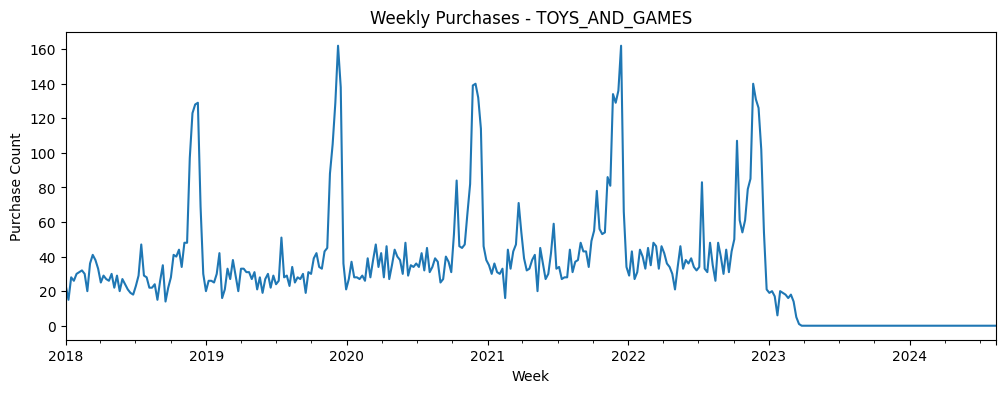

In [ ]:
import matplotlib.pyplot as plt

weekly_complete["TOYS_AND_GAMES"].plot(
    figsize=(12, 4)
)

plt.title("Weekly Purchases - TOYS_AND_GAMES")
plt.xlabel("Week")
plt.ylabel("Purchase Count")
plt.show()

In [ ]:
print("시작:", weekly_complete.index.min())
print("끝:", weekly_complete.index.max())

시작: 2018-01-01 00:00:00
끝: 2024-08-12 00:00:00


In [ ]:
print(
    weekly_complete["TOYS_AND_GAMES"]
    .tail(20)
)

2024-04-01    0.0
2024-04-08    0.0
2024-04-15    0.0
2024-04-22    0.0
2024-04-29    0.0
2024-05-06    0.0
2024-05-13    0.0
2024-05-20    0.0
2024-05-27    0.0
2024-06-03    0.0
2024-06-10    0.0
2024-06-17    0.0
2024-06-24    0.0
2024-07-01    0.0
2024-07-08    0.0
2024-07-15    0.0
2024-07-22    0.0
2024-07-29    0.0
2024-08-05    0.0
2024-08-12    0.0
Freq: 7D, Name: TOYS_AND_GAMES, dtype: float64


In [ ]:
# 2018~2022 분석 기간 설정

analysis_start = "2018-01-01"
analysis_end = "2022-12-31"

df = pd.read_csv(
    cleaned_path,
    parse_dates=["Order Date"]
)

print("정제 데이터 전체:", len(df))

df = df[
    (df["Order Date"] >= analysis_start) &
    (df["Order Date"] <= analysis_end)
].copy()

print("2018~2022:", len(df))
print("시작:", df["Order Date"].min())
print("끝:", df["Order Date"].max())

정제 데이터 전체: 1809241
2018~2022: 1770219
시작: 2018-01-01 00:00:00
끝: 2022-12-31 00:00:00


In [ ]:
print("ASIN 결측:", df["ASIN/ISBN (Product Code)"].isna().sum())
print("Category 결측:", df["Category"].isna().sum())

ASIN 결측: 943
Category 결측: 89233


In [ ]:
print("ASIN만 결측:", (
    df["ASIN/ISBN (Product Code)"].isna()
    & df["Category"].notna()
).sum())

print("Category만 결측:", (
    df["ASIN/ISBN (Product Code)"].notna()
    & df["Category"].isna()
).sum())

print("둘 다 결측:", (
    df["ASIN/ISBN (Product Code)"].isna()
    & df["Category"].isna()
).sum())

ASIN만 결측: 555
Category만 결측: 88845
둘 다 결측: 388


In [ ]:
df = df.dropna(
    subset=[
        "ASIN/ISBN (Product Code)",
        "Category"
    ]
).copy()

print("결측 제거 후 행 수:", len(df))

결측 제거 후 행 수: 1680431


In [ ]:
print("완전 중복 행:", df.duplicated().sum())

완전 중복 행: 4970


In [ ]:
df = df.drop_duplicates().copy()

print("중복 제거 후 행 수:", len(df))

중복 제거 후 행 수: 1675461


In [ ]:
df["is_outlier"] = (
    (df["Purchase Price Per Unit"] > 1000) |
    (df["Quantity"] > 10)
)

print("이상치 행:", df["is_outlier"].sum())
print("정상 행:", (~df["is_outlier"]).sum())

이상치 행: 939
정상 행: 1674522


In [ ]:
df["ASIN/ISBN (Product Code)"] = (
    df["ASIN/ISBN (Product Code)"]
    .str.strip()
    .str.upper()
)

print(df["ASIN/ISBN (Product Code)"].head())

0    B0143RTB1E
1    B01MA1MJ6H
3    B06XWF9HML
4    B00837ZOI0
5    B01GFB2E9M
Name: ASIN/ISBN (Product Code), dtype: object


In [ ]:
output_path = "/content/drive/MyDrive/purchases_clean_2018_2022.csv"

df.to_csv(
    output_path,
    index=False
)

print("저장 완료:", output_path)
print("행 수:", len(df))

저장 완료: /content/drive/MyDrive/purchases_clean_2018_2022.csv
행 수: 1675461


In [ ]:
target_products = [
    "TOILET_PAPER",
    "SURFACE_CLEANING_WIPE",
    "PUZZLES",
    "BAKING_PAN",
    "BLANKET",
    "DRINKING_CUP"
]

df_target = df[
    df["Category"].isin(target_products)
].copy()

print("6개 품목 행 수:", len(df_target))
print("\n품목별 행 수:")
print(df_target["Category"].value_counts())

6개 품목 행 수: 24770

품목별 행 수:
Category
DRINKING_CUP             7637
BLANKET                  5553
TOILET_PAPER             4727
PUZZLES                  3336
BAKING_PAN               1789
SURFACE_CLEANING_WIPE    1728
Name: count, dtype: int64


In [ ]:
# 주문일을 해당 주의 일요일 날짜로 변환

df_target["week"] = (
    df_target["Order Date"]
    - pd.to_timedelta(
        (df_target["Order Date"].dt.dayofweek + 1) % 7,
        unit="D"
    )
)

print(df_target[["Order Date", "week"]].head(10))

     Order Date       week
28   2019-09-28 2019-09-22
147  2018-02-11 2018-02-11
244  2019-01-02 2018-12-30
283  2019-07-20 2019-07-14
364  2020-02-07 2020-02-02
512  2020-10-23 2020-10-18
899  2021-06-22 2021-06-20
978  2021-08-24 2021-08-22
1057 2021-12-14 2021-12-12
1116 2022-02-02 2022-01-30


In [ ]:
weekly_purchase = (
    df_target
    .groupby(["week", "Category"])
    .agg(
        purchase_count=("Category", "size"),
        quantity_sum=("Quantity", "sum")
    )
    .reset_index()
    .rename(columns={"Category": "product_type"})
)

print(weekly_purchase.head(10))
print("\n행 수:", len(weekly_purchase))

        week           product_type  purchase_count  quantity_sum
0 2017-12-31             BAKING_PAN               7           8.0
1 2017-12-31                BLANKET               4           4.0
2 2017-12-31           DRINKING_CUP              14          14.0
3 2017-12-31                PUZZLES               2           3.0
4 2017-12-31  SURFACE_CLEANING_WIPE               7           7.0
5 2017-12-31           TOILET_PAPER               7           7.0
6 2018-01-07             BAKING_PAN               6           6.0
7 2018-01-07                BLANKET               9           9.0
8 2018-01-07           DRINKING_CUP              17          19.0
9 2018-01-07                PUZZLES               3           3.0

행 수: 1555


In [ ]:
print("최소 week:", weekly_purchase["week"].min())
print("최대 week:", weekly_purchase["week"].max())
print("고유 week 수:", weekly_purchase["week"].nunique())

print("\n상품별 week 수:")
print(weekly_purchase.groupby("product_type")["week"].nunique())

최소 week: 2017-12-31 00:00:00
최대 week: 2022-12-25 00:00:00
고유 week 수: 261

상품별 week 수:
product_type
BAKING_PAN               258
BLANKET                  261
DRINKING_CUP             261
PUZZLES                  259
SURFACE_CLEANING_WIPE    255
TOILET_PAPER             261
Name: week, dtype: int64


In [ ]:
# 6개 상품 × 261주 전체 조합 만들기
all_weeks = pd.date_range(
    start=weekly_purchase["week"].min(),
    end=weekly_purchase["week"].max(),
    freq="W-SUN"
)

all_products = target_products

full_index = pd.MultiIndex.from_product(
    [all_weeks, all_products],
    names=["week", "product_type"]
)

weekly_full = (
    weekly_purchase
    .set_index(["week", "product_type"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(weekly_full.head(10))
print("\n행 수:", len(weekly_full))
print("\n상품별 행 수:")
print(weekly_full.groupby("product_type").size())

        week           product_type  purchase_count  quantity_sum
0 2017-12-31           TOILET_PAPER               7           7.0
1 2017-12-31  SURFACE_CLEANING_WIPE               7           7.0
2 2017-12-31                PUZZLES               2           3.0
3 2017-12-31             BAKING_PAN               7           8.0
4 2017-12-31                BLANKET               4           4.0
5 2017-12-31           DRINKING_CUP              14          14.0
6 2018-01-07           TOILET_PAPER              14          15.0
7 2018-01-07  SURFACE_CLEANING_WIPE               6           7.0
8 2018-01-07                PUZZLES               3           3.0
9 2018-01-07             BAKING_PAN               6           6.0

행 수: 1566

상품별 행 수:
product_type
BAKING_PAN               261
BLANKET                  261
DRINKING_CUP             261
PUZZLES                  261
SURFACE_CLEANING_WIPE    261
TOILET_PAPER             261
dtype: int64


In [ ]:
# 각 응답자의 첫 구매일과 마지막 구매일
respondent_period = (
    df.groupby("Survey ResponseID")["Order Date"]
    .agg(
        first_purchase="min",
        last_purchase="max"
    )
    .reset_index()
)

print(respondent_period.head())
print("\n응답자 수:", len(respondent_period))

   Survey ResponseID first_purchase last_purchase
0  R_01vNIayewjIIKMF     2018-12-04    2022-06-10
1  R_037XK72IZBJyF69     2018-01-18    2022-12-13
2  R_038ZU6kfQ5f89fH     2019-01-16    2022-02-23
3  R_03aEbghUILs9NxD     2018-01-13    2022-12-22
4  R_06RZP9pS7kONINr     2018-01-23    2022-11-15

응답자 수: 5020


In [ ]:
active_by_week = []

for week in weekly_full["week"].unique():
    active_count = (
        (respondent_period["first_purchase"] <= week) &
        (respondent_period["last_purchase"] >= week)
    ).sum()

    active_by_week.append({
        "week": week,
        "active_respondents": active_count
    })

active_by_week = pd.DataFrame(active_by_week)

print(active_by_week.head(10))
print("\n최소:", active_by_week["active_respondents"].min())
print("최대:", active_by_week["active_respondents"].max())
print("행 수:", len(active_by_week))

        week  active_respondents
0 2017-12-31                   0
1 2018-01-07                1293
2 2018-01-14                1841
3 2018-01-21                2202
4 2018-01-28                2432
5 2018-02-04                2612
6 2018-02-11                2754
7 2018-02-18                2861
8 2018-02-25                2951
9 2018-03-04                3019

최소: 0
최대: 4818
행 수: 261


In [ ]:
weekly_full = weekly_full.merge(
    active_by_week,
    on="week",
    how="left"
)

print(weekly_full.head(10))
print("\n열 이름:")
print(weekly_full.columns.tolist())

        week           product_type  purchase_count  quantity_sum  \
0 2017-12-31           TOILET_PAPER               7           7.0   
1 2017-12-31  SURFACE_CLEANING_WIPE               7           7.0   
2 2017-12-31                PUZZLES               2           3.0   
3 2017-12-31             BAKING_PAN               7           8.0   
4 2017-12-31                BLANKET               4           4.0   
5 2017-12-31           DRINKING_CUP              14          14.0   
6 2018-01-07           TOILET_PAPER              14          15.0   
7 2018-01-07  SURFACE_CLEANING_WIPE               6           7.0   
8 2018-01-07                PUZZLES               3           3.0   
9 2018-01-07             BAKING_PAN               6           6.0   

   active_respondents  
0                   0  
1                   0  
2                   0  
3                   0  
4                   0  
5                   0  
6                1293  
7                1293  
8                1293  


In [ ]:
weekly_full["purchase_rate"] = (
    weekly_full["purchase_count"]
    / weekly_full["active_respondents"]
    * 1000
)

# active respondent가 0인 주는 계산 불가능하므로 NaN 처리
weekly_full.loc[
    weekly_full["active_respondents"] == 0,
    "purchase_rate"
] = pd.NA

print(weekly_full.head(10))
print("\npurchase_rate 결측:", weekly_full["purchase_rate"].isna().sum())

        week           product_type  purchase_count  quantity_sum  \
0 2017-12-31           TOILET_PAPER               7           7.0   
1 2017-12-31  SURFACE_CLEANING_WIPE               7           7.0   
2 2017-12-31                PUZZLES               2           3.0   
3 2017-12-31             BAKING_PAN               7           8.0   
4 2017-12-31                BLANKET               4           4.0   
5 2017-12-31           DRINKING_CUP              14          14.0   
6 2018-01-07           TOILET_PAPER              14          15.0   
7 2018-01-07  SURFACE_CLEANING_WIPE               6           7.0   
8 2018-01-07                PUZZLES               3           3.0   
9 2018-01-07             BAKING_PAN               6           6.0   

   active_respondents  purchase_rate  
0                   0            NaN  
1                   0            NaN  
2                   0            NaN  
3                   0            NaN  
4                   0            NaN  
5     

In [ ]:
weekly_final = weekly_full[
    [
        "week",
        "product_type",
        "purchase_count",
        "quantity_sum",
        "purchase_rate"
    ]
].copy()

print(weekly_final.head(10))
print("\n행 수:", len(weekly_final))
print("\n열:", weekly_final.columns.tolist())

        week           product_type  purchase_count  quantity_sum  \
0 2017-12-31           TOILET_PAPER               7           7.0   
1 2017-12-31  SURFACE_CLEANING_WIPE               7           7.0   
2 2017-12-31                PUZZLES               2           3.0   
3 2017-12-31             BAKING_PAN               7           8.0   
4 2017-12-31                BLANKET               4           4.0   
5 2017-12-31           DRINKING_CUP              14          14.0   
6 2018-01-07           TOILET_PAPER              14          15.0   
7 2018-01-07  SURFACE_CLEANING_WIPE               6           7.0   
8 2018-01-07                PUZZLES               3           3.0   
9 2018-01-07             BAKING_PAN               6           6.0   

   purchase_rate  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
5            NaN  
6      10.827533  
7       4.640371  
8       2.320186  
9       4.640371  

행 수: 1566

열: ['week', 'produc

In [ ]:
weekly_path = "/content/drive/MyDrive/weekly_purchase_final.csv"

weekly_final.to_csv(
    weekly_path,
    index=False
)

print("저장 완료:", weekly_path)

저장 완료: /content/drive/MyDrive/weekly_purchase_final.csv


In [ ]:
asin_category_check = (
    df_target
    .groupby("ASIN/ISBN (Product Code)")["Category"]
    .nunique()
)

print("ASIN 수:", len(asin_category_check))
print(
    "여러 Category에 연결된 ASIN 수:",
    (asin_category_check > 1).sum()
)

ASIN 수: 13808
여러 Category에 연결된 ASIN 수: 1


In [ ]:
multi_asins = asin_category_check[
    asin_category_check > 1
].index

print(
    df_target[
        df_target["ASIN/ISBN (Product Code)"].isin(multi_asins)
    ][
        ["ASIN/ISBN (Product Code)", "Category", "Title"]
    ].drop_duplicates()
)

       ASIN/ISBN (Product Code)               Category  \
217029               B005NIKG4E  SURFACE_CLEANING_WIPE   
589679               B005NIKG4E           DRINKING_CUP   

                                                    Title  
217029  Lens Cleaning Wipes by Bausch & Lomb, Pre-Mois...  
589679  Lens Cleaning Wipes by Bausch & Lomb, Pre-Mois...  


In [ ]:
df_target_asin = df_target[
    ~(
        (df_target["ASIN/ISBN (Product Code)"] == "B005NIKG4E") &
        (df_target["Category"] == "DRINKING_CUP")
    )
].copy()

print("기존 행 수:", len(df_target))
print("수정 후 행 수:", len(df_target_asin))

print(
    df_target_asin[
        df_target_asin["ASIN/ISBN (Product Code)"] == "B005NIKG4E"
    ][
        ["ASIN/ISBN (Product Code)", "Category", "Title"]
    ].drop_duplicates()
)

기존 행 수: 24770
수정 후 행 수: 24767
       ASIN/ISBN (Product Code)               Category  \
217029               B005NIKG4E  SURFACE_CLEANING_WIPE   

                                                    Title  
217029  Lens Cleaning Wipes by Bausch & Lomb, Pre-Mois...  


In [ ]:
asin_list = (
    df_target_asin
    .groupby(
        ["ASIN/ISBN (Product Code)", "Category"]
    )
    .size()
    .reset_index(name="purchase_rows")
    .rename(columns={
        "ASIN/ISBN (Product Code)": "asin",
        "Category": "product_type"
    })
)

print(asin_list.head(10))
print("\nASIN 리스트 행 수:", len(asin_list))
print("\n상품별 ASIN 수:")
print(asin_list.groupby("product_type")["asin"].nunique())

         asin product_type  purchase_rows
0  0439738628      PUZZLES              1
1  0553509799      PUZZLES              1
2  0692189823      PUZZLES              1
3  073533305X      PUZZLES              1
4  0735333416      PUZZLES              3
5  0735340080      PUZZLES              1
6  0735345724      PUZZLES              1
7  0735345759      PUZZLES              1
8  0735347468      PUZZLES              1
9  0735348200      PUZZLES              1

ASIN 리스트 행 수: 13808

상품별 ASIN 수:
product_type
BAKING_PAN               1070
BLANKET                  4242
DRINKING_CUP             5623
PUZZLES                  2277
SURFACE_CLEANING_WIPE     244
TOILET_PAPER              352
Name: asin, dtype: int64


In [ ]:
asin_path = "/content/drive/MyDrive/asin_list.csv"

asin_list.to_csv(
    asin_path,
    index=False
)

print("저장 완료:", asin_path)

저장 완료: /content/drive/MyDrive/asin_list.csv
